# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 113s 1us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

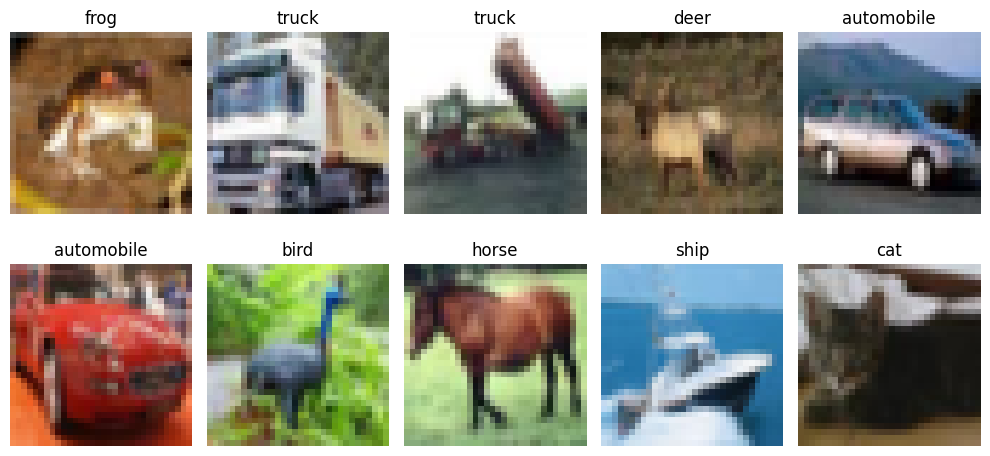

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.2757 - loss: 1.9861 - val_accuracy: 0.3338 - val_loss: 1.8294
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3133 - loss: 1.8757 - val_accuracy: 0.3416 - val_loss: 1.7832
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3348 - loss: 1.8213 - val_accuracy: 0.3726 - val_loss: 1.7415
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3527 - loss: 1.7796 - val_accuracy: 0.3880 - val_loss: 1.7196
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3618 - loss: 1.7516 - val_accuracy: 0.3992 - val_loss: 1.6972
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3724 - loss: 1.7217 - val_accuracy: 0.4034 - val_loss: 1.6797
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3811 - loss: 1.7108 - val_accuracy: 0.4162 - val_loss: 1.6633
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3839 - loss: 1.6949 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4354 - loss: 1.6222
ANN Test Accuracy: 0.43540000915527344


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 128ms/step - accuracy: 0.4673 - loss: 1.4899 - val_accuracy: 0.5576 - val_loss: 1.2703
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.6016 - loss: 1.1350 - val_accuracy: 0.5272 - val_loss: 1.3983
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 126ms/step - accuracy: 0.6672 - loss: 0.9593 - val_accuracy: 0.6830 - val_loss: 0.9207
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7061 - loss: 0.8449 - val_accuracy: 0.6964 - val_loss: 0.8822
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7391 - loss: 0.7432 - val_accuracy: 0.6432 - val_loss: 1.1755
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7642 - loss: 0.6707 - val_accuracy: 0.6624 - val_loss: 0.9874
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7896 - loss: 0.6016 - val_accuracy: 0.7226 - val_loss: 0.8366
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 129ms/step - accuracy: 0.8111 - loss

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7226 - loss: 0.9701
CNN Test Accuracy: 0.722599983215332


## 📈 Compare Learning Curves

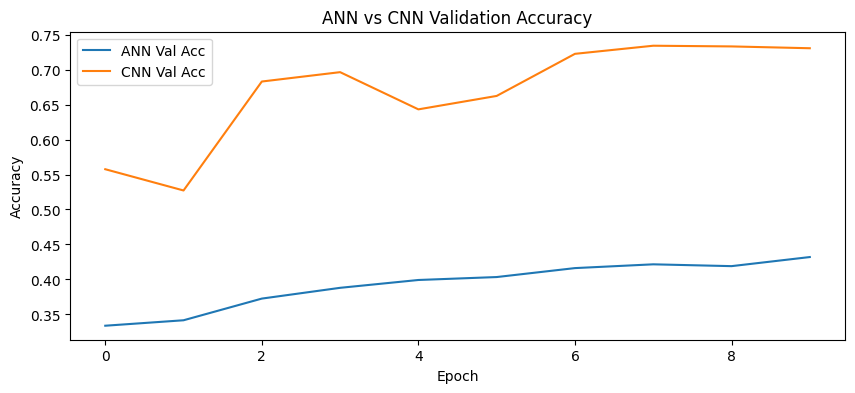

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4354
1,CNN,0.7226


In [13]:
# Task 1: Increased ANN Layers

ann_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_deep.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_deep_loss, ann_deep_acc = ann_deep.evaluate(x_test_flat, y_test)

print("Deep ANN Test Accuracy:", ann_deep_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.2063 - loss: 2.0992 - val_accuracy: 0.2688 - val_loss: 1.9508
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.2600 - loss: 1.9676 - val_accuracy: 0.3146 - val_loss: 1.9037
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.2916 - loss: 1.9133 - val_accuracy: 0.2962 - val_loss: 1.9070
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3056 - loss: 1.8855 - val_accuracy: 0.3222 - val_loss: 1.8484
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3162 - loss: 1.8603 - val_accuracy: 0.3434 - val_loss: 1.8166
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3269 - loss: 1.8420 - val_accuracy: 0.3350 - val_loss: 1.8493
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3315 - loss: 1.8290 - val_accuracy: 0.3618 - val_loss: 1.8057
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3353 - loss: 1.8129 - 

After increasing the number of ANN layers, the test accuracy decreased from approximately 43.5% to 36.9%. This shows that simply adding more layers does not always improve performance. Since the model still uses flattened images, it is unable to effectively capture important image features.

In [14]:
## Task 2: Change CNN Filters from 32 → 64 → 128
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 128ms/step - accuracy: 0.4718 - loss: 1.4833 - val_accuracy: 0.4200 - val_loss: 1.7253
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.6126 - loss: 1.1114 - val_accuracy: 0.5634 - val_loss: 1.2699
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6666 - loss: 0.9505 - val_accuracy: 0.6120 - val_loss: 1.1595
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 127ms/step - accuracy: 0.7131 - loss: 0.8281 - val_accuracy: 0.6800 - val_loss: 0.9365
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.7453 - loss: 0.7284 - val_accuracy: 0.6954 - val_loss: 0.9184
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7700 - loss: 0.6544 - val_accuracy: 0.7200 - val_loss: 0.8272
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7947 - loss: 0.5847 - val_accuracy: 0.7458 - val_loss: 0.7666
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 127ms/step - accuracy: 0.8116 - loss

Increasing the number of filters in deeper layers helps the network learn more detailed image features.  CNN was able to classify images much more accurately than t ANN because it preserved spatial information throughout the learning process.

In [15]:
# Task 3: Increase Epochs to 20

cnn_20 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn20_history = cnn_20.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn20_loss, cnn20_acc = cnn_20.evaluate(x_test_norm, y_test)
print("CNN 20 Epoch Accuracy:", cnn20_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 129ms/step - accuracy: 0.4703 - loss: 1.4841 - val_accuracy: 0.4776 - val_loss: 1.4409
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.6058 - loss: 1.1250 - val_accuracy: 0.6426 - val_loss: 0.9979
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 129ms/step - accuracy: 0.6661 - loss: 0.9568 - val_accuracy: 0.6828 - val_loss: 0.9237
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7094 - loss: 0.8312 - val_accuracy: 0.5830 - val_loss: 1.3304
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7413 - loss: 0.7380 - val_accuracy: 0.6834 - val_loss: 0.9404
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.7694 - loss: 0.6502 - val_accuracy: 0.7314 - val_loss: 0.8155
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 126ms/step - accuracy: 0.7935 - loss: 0.5826 - val_accuracy: 0.7174 - val_loss: 0.8677
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.8113 - loss

After increasing the training epochs from 10 to 20, the test accuracy remained almost the same. The model achieved approximately 71.9% accuracy, which is very close to the result obtained with 10 epochs.Increasing the number of epochs does not always improve model performance. After a certain point, the model may stop learning useful patterns and additional training may provide little benefit.

In [17]:
## Task 4: Add EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es_history = cnn_es.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

es_loss, es_acc = cnn_es.evaluate(x_test_norm, y_test)

print("CNN EarlyStopping Accuracy:", es_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 142ms/step - accuracy: 0.4714 - loss: 1.4855 - val_accuracy: 0.5428 - val_loss: 1.3380
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.6117 - loss: 1.1099 - val_accuracy: 0.6102 - val_loss: 1.1010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.6737 - loss: 0.9406 - val_accuracy: 0.6924 - val_loss: 0.8899
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.7162 - loss: 0.8232 - val_accuracy: 0.6978 - val_loss: 0.8884
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7440 - loss: 0.7303 - val_accuracy: 0.7134 - val_loss: 0.8373
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7684 - loss: 0.6589 - val_accuracy: 0.6918 - val_loss: 0.9258
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 130ms/step - accuracy: 0.7929 - loss: 0.5886 - val_accuracy: 0.6888 - val_loss: 0.9595
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 130ms/step - accuracy: 0.8096 - los

After adding EarlyStopping, the training process stopped automatically when the validation loss stopped improving. The model achieved a test accuracy of approximately 70.6%. EarlyStopping helps prevent unnecessary training and can reduce overfitting by stopping the model when performance on the validation data no longer improves. Although the accuracy was slightly lower than the previous CNN model, the training process became more efficient.

In [20]:
## Task 5: Add Data Augmentation Training
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

print("Augmented CNN Accuracy:", aug_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5898 - loss: 1.1696 - val_accuracy: 0.6408 - val_loss: 1.0250
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5908 - loss: 1.1617 - val_accuracy: 0.6512 - val_loss: 0.9929
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5956 - loss: 1.1427 - val_accuracy: 0.6684 - val_loss: 0.9341
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.6062 - loss: 1.1220 - val_accuracy: 0.6380 - val_loss: 1.0320
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.6061 - loss: 1.1227 - val_accuracy: 0.6270 - val_loss: 1.0693
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 94ms/step - accuracy: 0.6097 - loss: 1.1096 - val_accuracy: 0.6690 - val_loss: 0.9357
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.6162 - loss: 1.0877 - val_accuracy: 0.6690 - val_loss: 0.9306
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 98ms/step - accuracy: 0.6195 - loss: 1.0853 - 

Data augmentation creates different variations of the training images, helping the model learn from more diverse data. Although the accuracy in this experiment was lower than the original CNN model, data augmentation can improve generalization and make the model more robust to variations in real world images.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**